In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [11]:
df = pd.read_csv('telecom_churn.csv', encoding='utf-8-sig', low_memory=False)

In [25]:
#TASK1

In [13]:
print(df.columns.tolist())

['state', 'account length', 'area code', 'phone number', 'international plan', 'voice mail plan', 'number vmail messages', 'total day minutes', 'total day calls', 'total day charge', 'total eve minutes', 'total eve calls', 'total eve charge', 'total night minutes', 'total night calls', 'total night charge', 'total intl minutes', 'total intl calls', 'total intl charge', 'customer service calls', 'churn']


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

In [15]:
df['churn'] = df['churn'].astype(int)

In [16]:
features = ['account length', 'total day charge', 'customer service calls', 'number vmail messages']
X = df[features]
y = df['churn']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, random_state=42)

In [18]:
model_a = LogisticRegression(max_iter=1000)
model_a.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [19]:
train_acc = accuracy_score(y_train, model_a.predict(X_train))
test_acc = accuracy_score(y_test, model_a.predict(X_test))

In [20]:
print(f"Part A: Baseline Model")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}\n")

Part A: Baseline Model
Train Accuracy: 0.8579
Test Accuracy: 0.8525



In [21]:
new_record = pd.DataFrame([[100, 45.0, 2, 0]], columns=features)
pred = model_a.predict(new_record)
print(f"Part B: Prediction for new record is: {'Churn' if pred[0] == 1 else 'No Churn'}\n")

Part B: Prediction for new record is: No Churn



In [22]:
norm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [23]:
norm_pipeline.fit(X_train, y_train)
norm_test_acc = accuracy_score(y_test, norm_pipeline.predict(X_test))

In [24]:
print(f"Part C: Normalized Model")
print(f"Normalized Test Accuracy: {norm_test_acc:.4f}")

Part C: Normalized Model
Normalized Test Accuracy: 0.8525


In [26]:
#TASK2

In [27]:
df['churn_num'] = df['churn'].astype(int)
churn_1 = df[df['churn'] == True].copy()

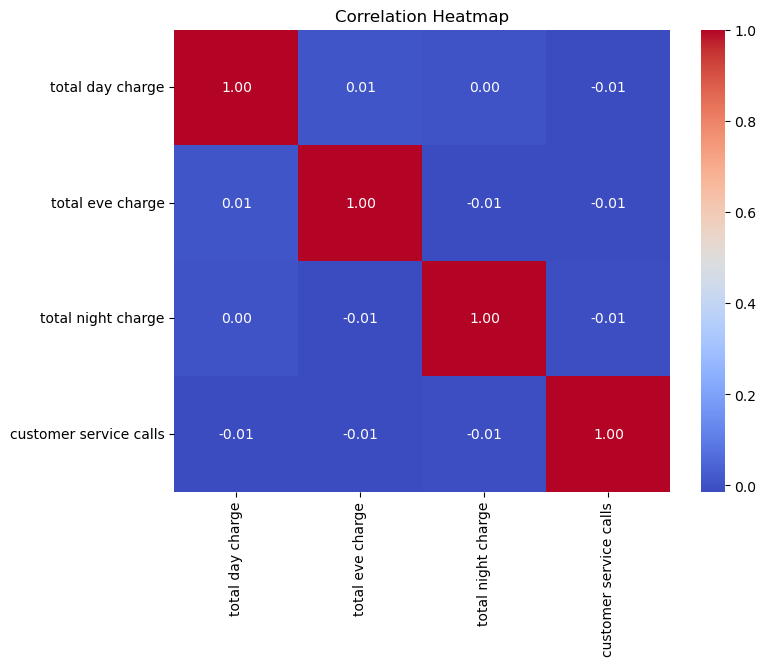

In [30]:
plt.figure(figsize=(8, 6))
selected_features = ['total day charge', 'total eve charge', 'total night charge', 'customer service calls']
sns.heatmap(df[selected_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

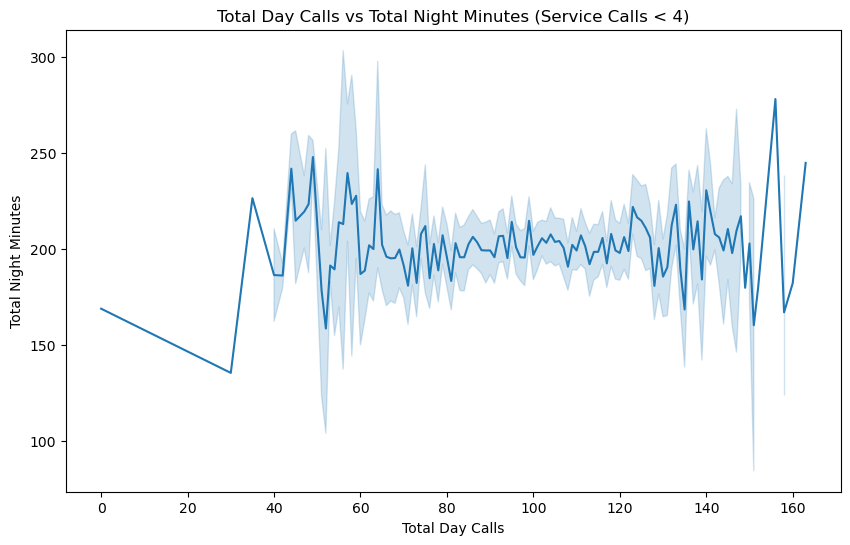

In [31]:
plt.figure(figsize=(10, 6))
filtered_df = df[df['customer service calls'] < 4].sort_values('total day calls')
sns.lineplot(data=filtered_df, x='total day calls', y='total night minutes')
plt.title('Total Day Calls vs Total Night Minutes (Service Calls < 4)')
plt.xlabel('Total Day Calls')
plt.ylabel('Total Night Minutes')
plt.show()

In [32]:
#TASK3

In [33]:
cluster_features = ['total day charge', 'total eve charge', 'customer service calls']
X_cluster = df[cluster_features]

In [34]:
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    sse.append(kmeans.inertia_)

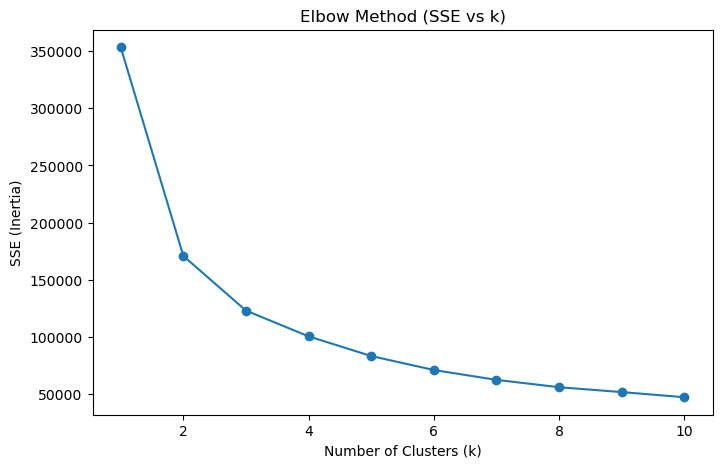

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), sse, marker='o')
plt.title('Elbow Method (SSE vs k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('SSE (Inertia)')
plt.show()

In [36]:
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df['label'] = kmeans_3.fit_predict(X_cluster)

In [39]:
#EXPLANATION FOR K=3: at 3 SSE decreases slows down significantly, balancing the group seperation and compactness

In [40]:
print("First 5 records with their cluster labels:")
print(df[['total day charge', 'total eve charge', 'customer service calls', 'label']].head())

First 5 records with their cluster labels:
   total day charge  total eve charge  customer service calls  label
0             45.07             16.78                       1      2
1             27.47             16.62                       1      0
2             41.38             10.30                       0      2
3             50.90              5.26                       2      2
4             28.34             12.61                       3      0


In [41]:
#TASK4

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [42]:
reg_features = ['account length', 'total day calls', 'customer service calls']
target = 'total day charge'

In [44]:
X_reg = df[reg_features]
y_reg = df[target]

In [45]:
lr_model = LinearRegression()
lr_model.fit(X_reg, y_reg)

LinearRegression()

In [46]:
print("--- Part B: Model Parameters ---")
print(f"Intercept (Beta 0): {lr_model.intercept_:.4f}")
for feature, coef in zip(reg_features, lr_model.coef_):
    print(f"Coefficient for {feature}: {coef:.4f}")

--- Part B: Model Parameters ---
Intercept (Beta 0): 30.2786
Coefficient for account length: 0.0014
Coefficient for total day calls: 0.0029
Coefficient for customer service calls: -0.0935


In [47]:
y_reg_pred = lr_model.predict(X_reg)
mse = mean_squared_error(y_reg, y_reg_pred)
print(f"\n--- Part C: Performance ---")
print(f"Mean Square Error: {mse:.4f}")


--- Part C: Performance ---
Mean Square Error: 85.6893


In [48]:
new_val_record = pd.DataFrame([[12, 17, 21]], columns=reg_features)
val_prediction = lr_model.predict(new_val_record)

In [49]:
print(f"\n--- Part D: Prediction ---")
print(f"Predicted '{target}' for values [12, 17, 21]: {val_prediction[0]:.4f}")


--- Part D: Prediction ---
Predicted 'total day charge' for values [12, 17, 21]: 28.3805
